--- Task 1: SVM Kernels ---
Linear SVM Test Accuracy: 0.977
RBF SVM Test Accuracy:    0.971

--- Task 2: KNN Parameter Tuning ---
KNN (k=3) Test Accuracy: 0.959
KNN (k=5) Test Accuracy: 0.959
KNN (k=7) Test Accuracy: 0.959

--- Task 3: 5-Fold Cross-Validation (on Full Training Set) ---
SVM RBF 5-Fold CV Mean Accuracy: 0.974 (+/- 0.029)
KNN (k=5) 5-Fold CV Mean Accuracy: 0.965 (+/- 0.019)



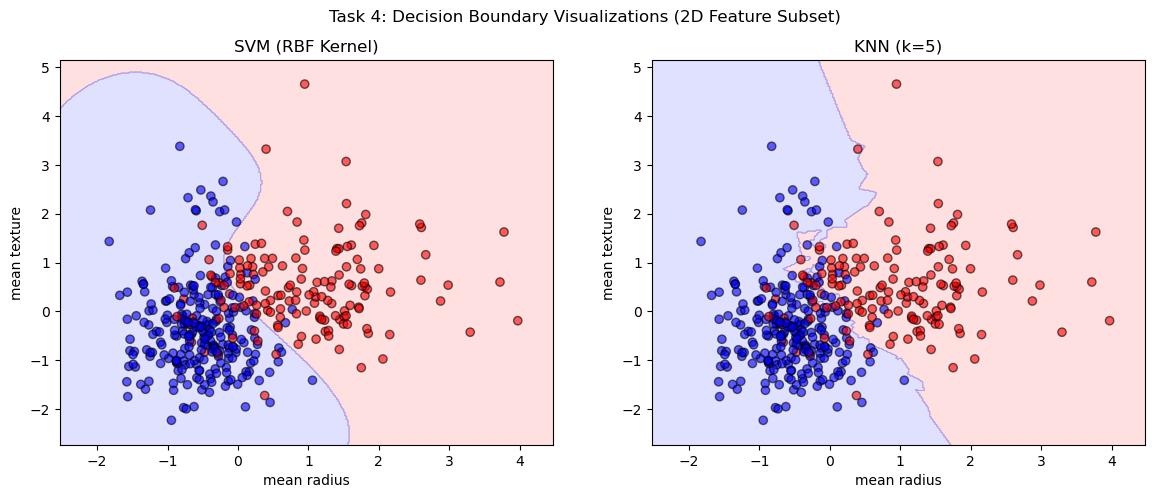

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# DATA PREPARATION & SCALING
# Load data
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

# Both SVM and KNN are distance-dependent algorithms. Scaling is mandatory!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# TASK 1: Train SVM (Linear and RBF Kernels)
print("--- Task 1: SVM Kernels ---")
svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train, y_train)
print(f"Linear SVM Test Accuracy: {accuracy_score(y_test, svm_linear.predict(X_test)):.3f}")

svm_rbf = SVC(kernel='rbf', random_state=42)
svm_rbf.fit(X_train, y_train)
print(f"RBF SVM Test Accuracy:    {accuracy_score(y_test, svm_rbf.predict(X_test)):.3f}\n")

# TASK 2: Train KNN with k=3, 5, 7
print("--- Task 2: KNN Parameter Tuning ---")
for k in [3, 5, 7]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test))
    print(f"KNN (k={k}) Test Accuracy: {acc:.3f}")
print()
# TASK 3: Perform 5-Fold Cross-Validation
# =====================================================================
print("--- Task 3: 5-Fold Cross-Validation (on Full Training Set) ---")
# Using RBF SVM and KNN (k=5) as representatives
cv_svm = cross_val_score(SVC(kernel='rbf', random_state=42), X_scaled, y, cv=5)
cv_knn = cross_val_score(KNeighborsClassifier(n_neighbors=5), X_scaled, y, cv=5)

print(f"SVM RBF 5-Fold CV Mean Accuracy: {cv_svm.mean():.3f} (+/- {cv_svm.std()*2:.3f})")
print(f"KNN (k=5) 5-Fold CV Mean Accuracy: {cv_knn.mean():.3f} (+/- {cv_knn.std()*2:.3f})\n")
# TASK 4: Plot Decision Boundary for a 2D Feature Subset
# =====================================================================
# We will select the first 2 features ("mean radius" and "mean texture") for visualization
X_2d = X_scaled[:, :2]
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(X_2d, y, test_size=0.3, random_state=42)

# Instantiate models for 2D plotting
models = {
    'SVM (RBF Kernel)': SVC(kernel='rbf', random_state=42),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5)
}

# Create a mesh grid to plot boundaries
x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, model) in zip(axes, models.items()):
    model.fit(X_train_2d, y_train_2d)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot decision regions
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FF9999', '#9999FF']))
    
    # Plot training points
    scatter = ax.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train_2d, 
                         cmap=ListedColormap(['#FF0000', '#0000FF']), edgecolors='k', alpha=0.6)
    
    ax.set_title(name)
    ax.set_xlabel(cancer.feature_names[0])
    ax.set_ylabel(cancer.feature_names[1])

plt.suptitle("Task 4: Decision Boundary Visualizations (2D Feature Subset)")
plt.show()

In [3]:
from sklearn.datasets import load_digits
from sklearn.metrics import classification_report

# =====================================================================
# PRACTICE SHEET: MNIST/Digits Subsets
# =====================================================================
print("--- Practice Sheet: Handwritten Digit Classification ---")

# Load built-in 8x8 pixel image digits dataset (MNIST subset alternative)
digits = load_digits()
X_dig = digits.data
y_dig = digits.target

# Standardize feature data
scaler_dig = StandardScaler()
X_dig_scaled = scaler_dig.fit_transform(X_dig)

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_dig_scaled, y_dig, test_size=0.3, random_state=42)

# 1. Handwritten digit classification using KNN
print("Evaluating KNN (k=3) on Digits Data:")
knn_digits = KNeighborsClassifier(n_neighbors=3)
knn_digits.fit(X_train_d, y_train_d)
y_pred_knn = knn_digits.predict(X_test_d)
print(f"Overall Accuracy: {accuracy_score(y_test_d, y_pred_knn):.3f}\n")

# 2. Compare SVM kernel types (linear, poly, rbf)
kernels = ['linear', 'poly', 'rbf']
svm_results = {}

print("Comparing SVM Kernel Performance on Digits:")
for kernel in kernels:
    svm_dig = SVC(kernel=kernel, random_state=42)
    svm_dig.fit(X_train_d, y_train_d)
    y_pred_svm = svm_dig.predict(X_test_d)
    acc = accuracy_score(y_test_d, y_pred_svm)
    svm_results[kernel] = acc
    print(f"SVM with {kernel.upper()} kernel accuracy: {acc:.3f}")

# Detailed breakdown of the best performing model
best_kernel = max(svm_results, key=svm_results.get)
print(f"\nDetailed Classification Report for the Best Model (SVM - {best_kernel.upper()}):")
best_svm = SVC(kernel=best_kernel, random_state=42)
best_svm.fit(X_train_d, y_train_d)
print(classification_report(y_test_d, best_svm.predict(X_test_d)))

--- Practice Sheet: Handwritten Digit Classification ---
Evaluating KNN (k=3) on Digits Data:
Overall Accuracy: 0.967

Comparing SVM Kernel Performance on Digits:
SVM with LINEAR kernel accuracy: 0.978
SVM with POLY kernel accuracy: 0.939
SVM with RBF kernel accuracy: 0.981

Detailed Classification Report for the Best Model (SVM - RBF):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       1.00      1.00      1.00        50
           2       0.94      1.00      0.97        47
           3       0.98      0.94      0.96        54
           4       1.00      1.00      1.00        60
           5       0.97      1.00      0.99        66
           6       0.98      1.00      0.99        53
           7       1.00      0.98      0.99        55
           8       0.95      0.95      0.95        43
           9       0.98      0.93      0.96        59

    accuracy                           0.98       540
   macro av